In [1]:
import os
import vtk
import numpy as np
from utilities import ReadVTPFile, GetCentroid, ReadVTKFile, WriteVTIFile, WriteVTPFile, ThresholdInBetween, ExtractSurface, LargestConnectedRegion
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

In [8]:
InputFolder = "/Users/ana/Documents/AnahitaSeresti/05_PrePostCABG/EjectionFractionCalculation/SU24A-CCTA"
slice_base = "Slice_Base.vtp"
slice_apex = "Slice_Apex.vtp"
image_ = "SU24A_CCTA_Registered.vtk"
point_base = GetCentroid(ReadVTPFile(os.path.join(InputFolder,slice_base)))
point_apex = GetCentroid(ReadVTPFile(os.path.join(InputFolder, slice_apex)))

In [9]:
CL_direction = [
    point_base[0] - point_apex[0],
    point_base[1] - point_apex[1],
    point_base[2] - point_apex[2]
                ]

CL_direction /= np.linalg.norm(CL_direction)
np.linalg.norm(CL_direction)

0.9999999999999999

In [4]:
z_axis = CL_direction
x_axis = [-z_axis[2], 0, z_axis[0]]
y_axis = np.cross(x_axis, z_axis)

In [10]:
center = [
    (point_base[0] + point_apex[0])/2,
    (point_base[1] + point_apex[1])/2,
    (point_base[2] + point_apex[2])/2
]
center

[4.022712448639073, -20.33479918729179, -22.4192670263446]

In [11]:
def SliceWPlane(Volume,Origin,Norm):
    plane=vtk.vtkPlane()
    plane.SetOrigin(Origin)
    plane.SetNormal(Norm)
    Slice=vtk.vtkCutter()
    Slice.GenerateTrianglesOff()
    Slice.SetCutFunction(plane)
    Slice.SetInputData(Volume)
    Slice.Update()
    
    return Slice.GetOutput()

In [12]:
image = ReadVTKFile(os.path.join(InputFolder, image_))
sample_slice = SliceWPlane(image, center, CL_direction)
WriteVTPFile(os.path.join(InputFolder, "sampleslice.vtp"), sample_slice)


## Testing a Sample Slice in the Center of The LV

In [13]:
scalar_array_name = image.GetPointData().GetScalars().GetName()
BloodPool = ThresholdInBetween(sample_slice, scalar_array_name, 200, 700)
BloodPool = ExtractSurface(LargestConnectedRegion(BloodPool))

bp_centroid = GetCentroid(BloodPool)


In [14]:
from scipy.spatial.transform import Rotation as R
rotation, _ = R.align_vectors([[0, 0, 1]], [CL_direction])

def Rotate(slice, scalar_array_name):
    new_point_x = []
    new_point_y = []

    for i in range(slice.GetNumberOfPoints()):
        point_ = rotation.apply(slice.GetPoint(i))
        new_point_x.append(point_[0])
        new_point_y.append(point_[1])

    new_point_x = np.array(new_point_x)
    new_point_y = np.array(new_point_y)
    scalar_value = vtk_to_numpy(slice.GetPointData().GetArray(scalar_array_name))
    return new_point_x, new_point_y, scalar_value

/var/folders/05/bygg4rdj3n7543jkngl6k6z40000gn/T/ipykernel_74330/4141764151.py:2: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  rotation, _ = R.align_vectors([[0, 0, 1]], [CL_direction])


17.94047004208806 2.389692234824551


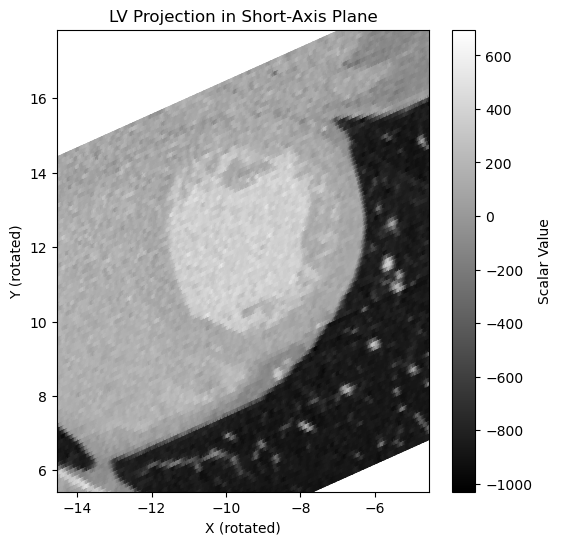

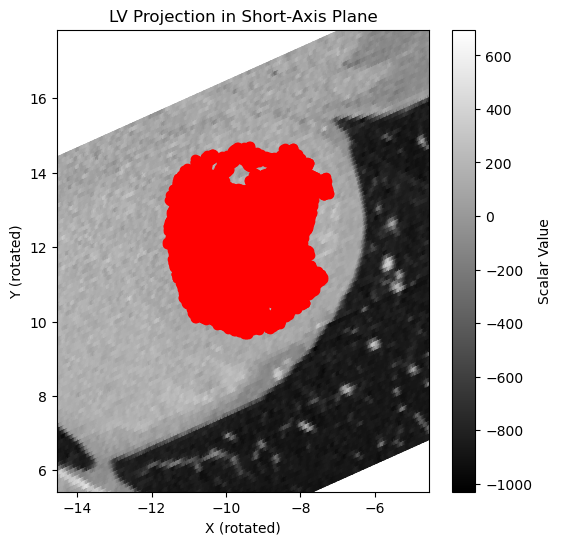

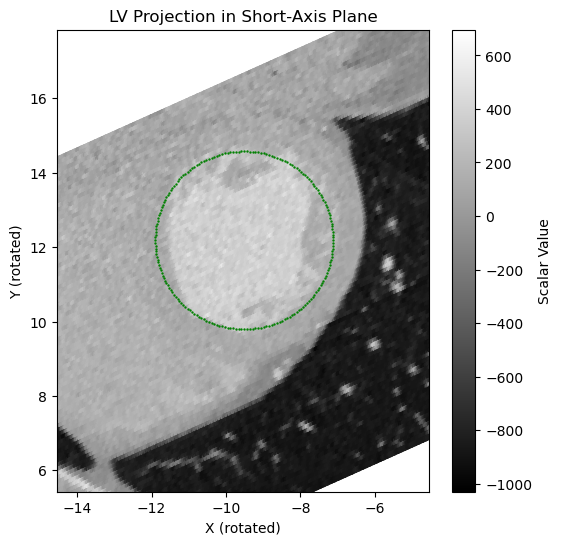

In [15]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull


center_rotated = rotation.apply(center)
centroid_rotated = rotation.apply(bp_centroid)


new_point_x, new_point_y, scalar_value = Rotate(sample_slice, scalar_array_name)
new_point_x_bp, new_point_y_bp, scalar_value_bp = Rotate(BloodPool, scalar_array_name)

coords_2d = np.column_stack((new_point_x_bp, new_point_y_bp))
hull = ConvexHull(coords_2d)
hull_area = hull.volume

radius = np.sqrt(hull_area/np.pi)
print(hull_area, radius)

plt.figure(figsize=(6, 6))
sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10)
plt.colorbar(sc, label='Scalar Value')
plt.axis('equal')
plt.xlabel('X (rotated)')
plt.ylabel('Y (rotated)')
plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
plt.title('LV Projection in Short-Axis Plane')
plt.show()


plt.figure(figsize=(6, 6))
sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10)
plt.scatter(new_point_x_bp, new_point_y_bp, color='red')
plt.colorbar(sc, label='Scalar Value')
plt.axis('equal')
plt.xlabel('X (rotated)')
plt.ylabel('Y (rotated)')
plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
plt.title('LV Projection in Short-Axis Plane')
plt.show()

x_circle = []
y_circle = []
for theta in np.arange(0,np.pi*2, np.pi/100):
    x_circle.append(centroid_rotated[0] + radius*np.cos(theta))
    y_circle.append(centroid_rotated[1] + radius*np.sin(theta))

plt.figure(figsize=(6, 6))
sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10)
plt.scatter(x_circle, y_circle, color='green', s = 0.5)
plt.colorbar(sc, label='Scalar Value')
plt.axis('equal')
plt.xlabel('X (rotated)')
plt.ylabel('Y (rotated)')
plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
plt.title('LV Projection in Short-Axis Plane')
plt.show()


## Finding Basal Point

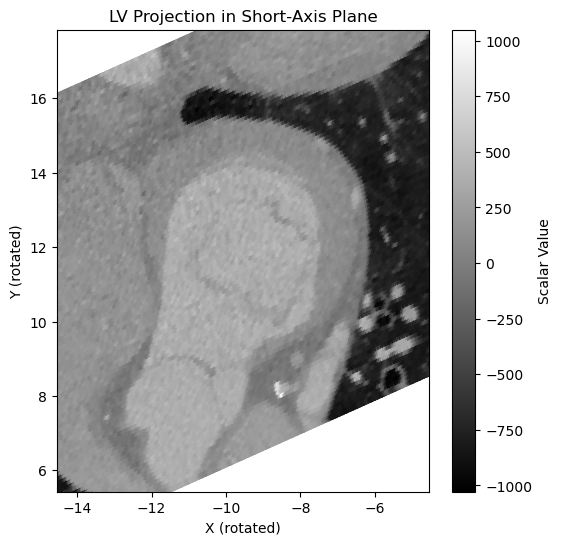

In [16]:
point_1 = [
    center[0] + 4.5*CL_direction[0],
    center[1] + 4.5*CL_direction[1],
    center[2] + 4.5*CL_direction[2]
]

slice_1 = SliceWPlane(image, point_1, CL_direction)
#BloodPool = ThresholdInBetween(slice_1, scalar_array_name, 200, 700)
#BloodPool = ExtractSurface(LargestConnectedRegion(BloodPool))

#bp_centroid = GetCentroid(BloodPool)

center_rotated = rotation.apply(center)
#centroid_rotated = rotation.apply(bp_centroid)


new_point_x, new_point_y, scalar_value = Rotate(slice_1, scalar_array_name)
#new_point_x_bp, new_point_y_bp, scalar_value_bp = Rotate(BloodPool, scalar_array_name)

#coords_2d = np.column_stack((new_point_x_bp, new_point_y_bp))
#hull = ConvexHull(coords_2d)
#hull_area = hull.volume

#radius = np.sqrt(hull_area/np.pi)
#print(hull_area, radius)

plt.figure(figsize=(6, 6))
sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10)
plt.colorbar(sc, label='Scalar Value')
plt.axis('equal')
plt.xlabel('X (rotated)')
plt.ylabel('Y (rotated)')
plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
plt.title('LV Projection in Short-Axis Plane')
plt.show()


## Finding Apical Point

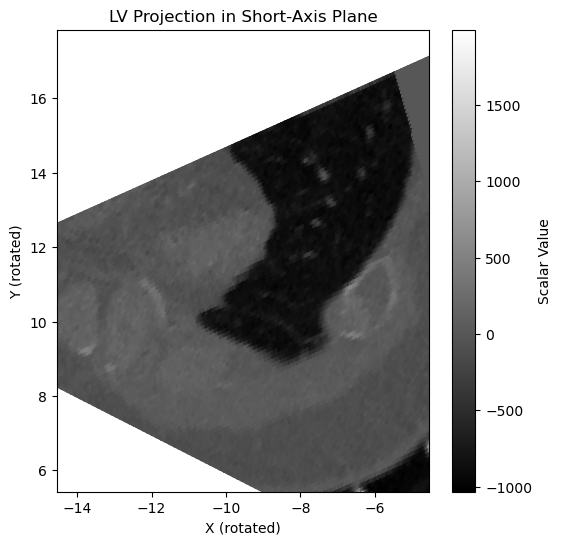

In [17]:
point_2 = [
    center[0] - 4.7*CL_direction[0],
    center[1] - 4.7*CL_direction[1],
    center[2] - 4.7*CL_direction[2]
]

slice_2 = SliceWPlane(image, point_2, CL_direction)
#BloodPool = ThresholdInBetween(slice_1, scalar_array_name, 200, 700)
#BloodPool = ExtractSurface(LargestConnectedRegion(BloodPool))

#bp_centroid = GetCentroid(BloodPool)

center_rotated = rotation.apply(center)
#centroid_rotated = rotation.apply(bp_centroid)


new_point_x, new_point_y, scalar_value = Rotate(slice_2, scalar_array_name)
#new_point_x_bp, new_point_y_bp, scalar_value_bp = Rotate(BloodPool, scalar_array_name)

#coords_2d = np.column_stack((new_point_x_bp, new_point_y_bp))
#hull = ConvexHull(coords_2d)
#hull_area = hull.volume

#radius = np.sqrt(hull_area/np.pi)
#print(hull_area, radius)

plt.figure(figsize=(6, 6))
sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10)
plt.colorbar(sc, label='Scalar Value')
plt.axis('equal')
plt.xlabel('X (rotated)')
plt.ylabel('Y (rotated)')
plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
plt.title('LV Projection in Short-Axis Plane')
plt.show()

In [18]:
length_LV = [
    point_1[0] - point_2[0],
    point_1[1] - point_2[1],
    point_1[2] - point_2[2]
]
length_LV = np.linalg.norm(length_LV)

N_Slices = 20

slice_thickness = length_LV/N_Slices
slice_thickness

0.45999999999999985

In [19]:
def Line(point1, point2, res):
    line = vtk.vtkLineSource()
    line.SetPoint1(point1)
    line.SetPoint2(point2)
    line.SetResolution(res)
    line.Update()
    
    return line.GetOutput()

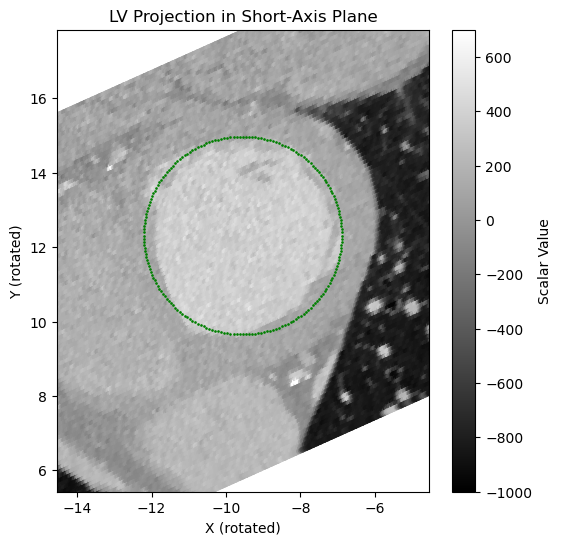

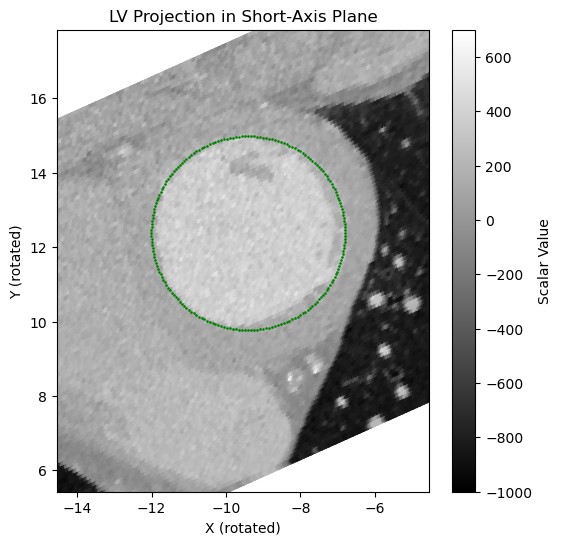

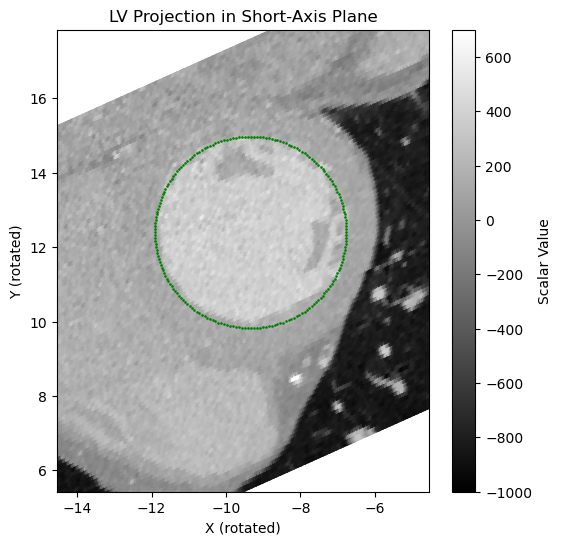

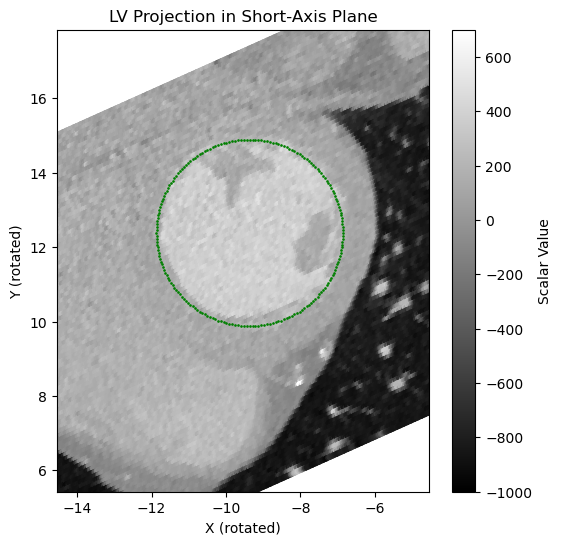

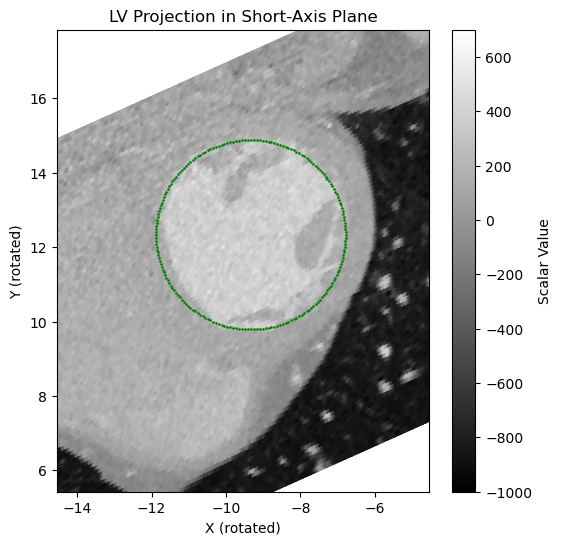

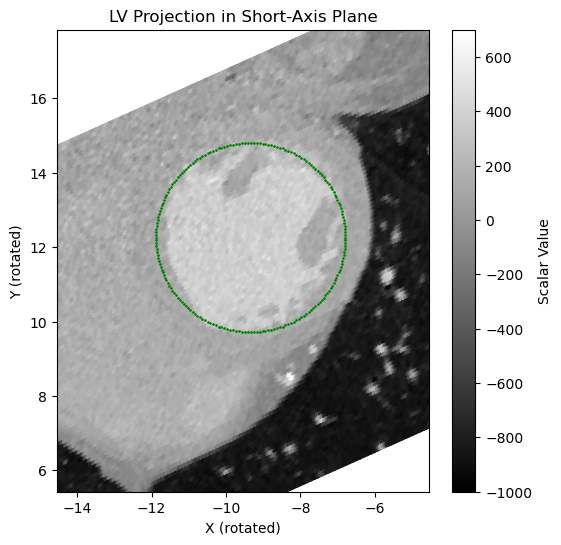

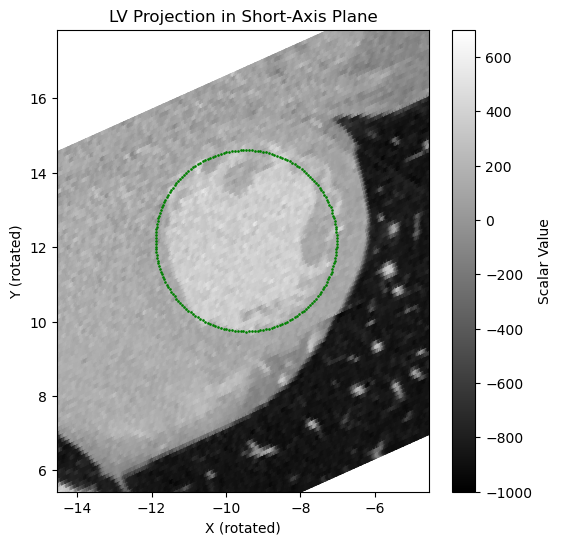

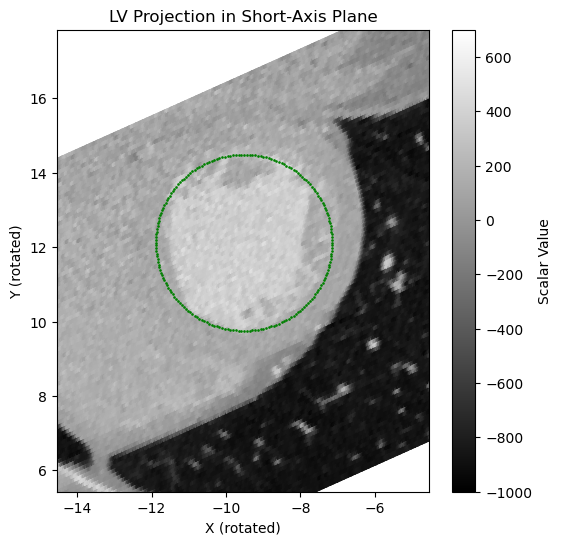

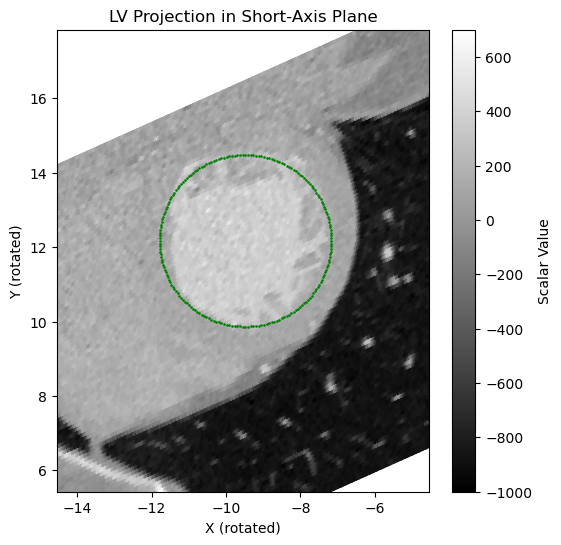

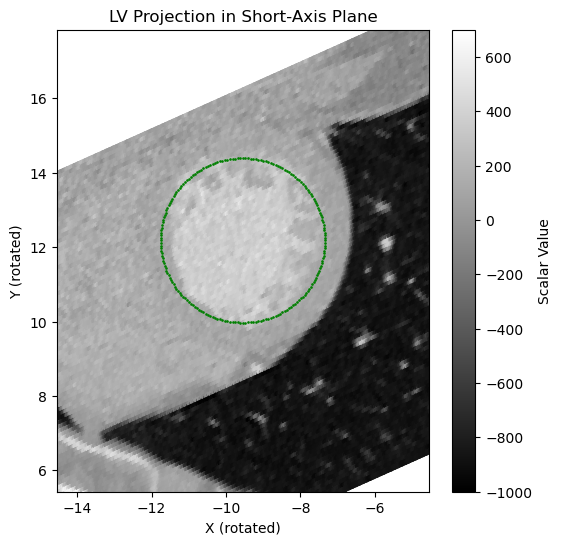

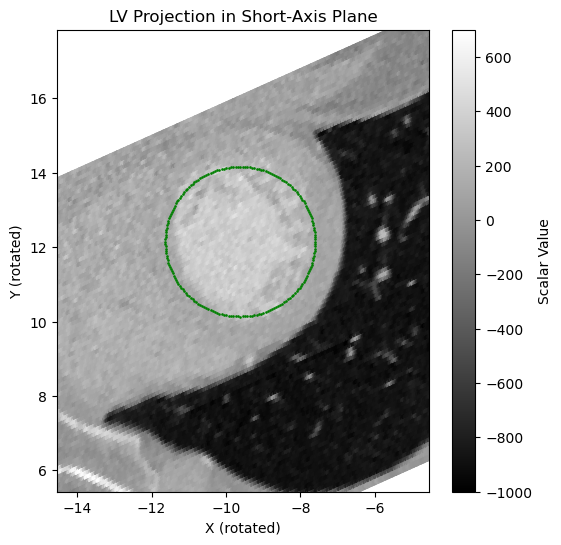

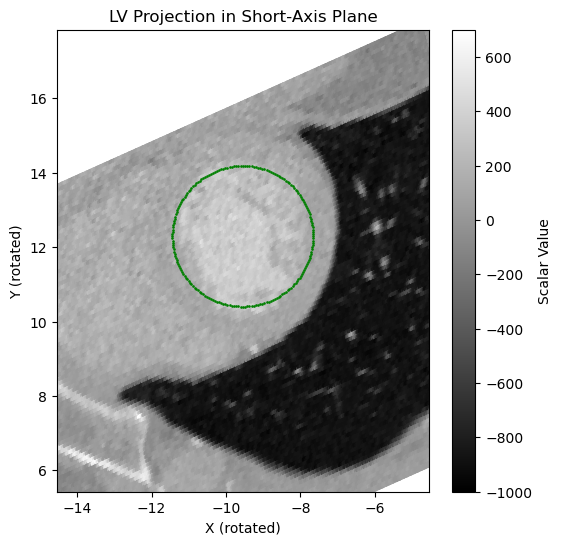

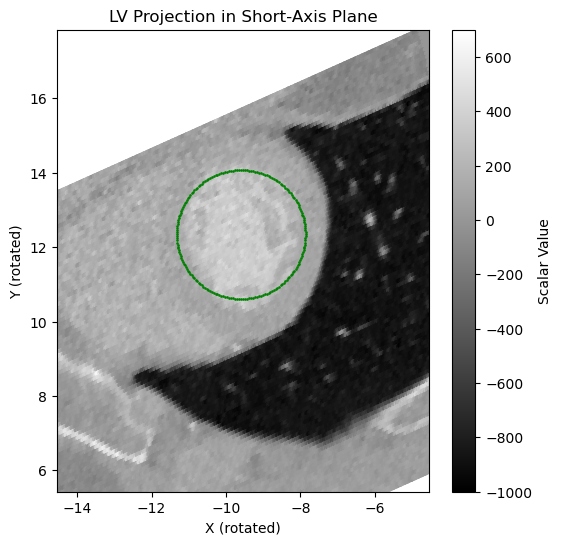

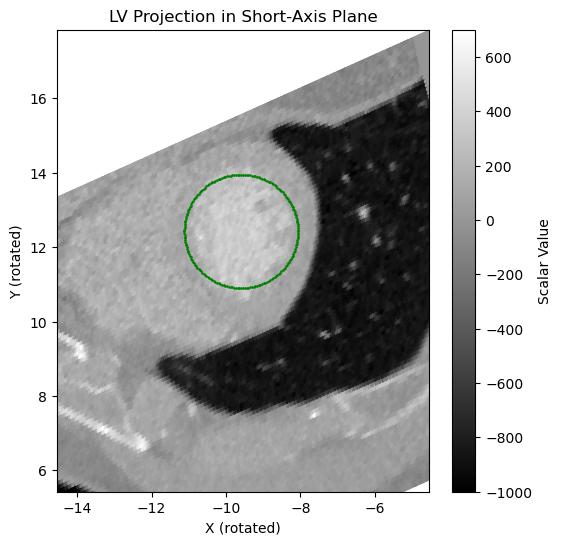

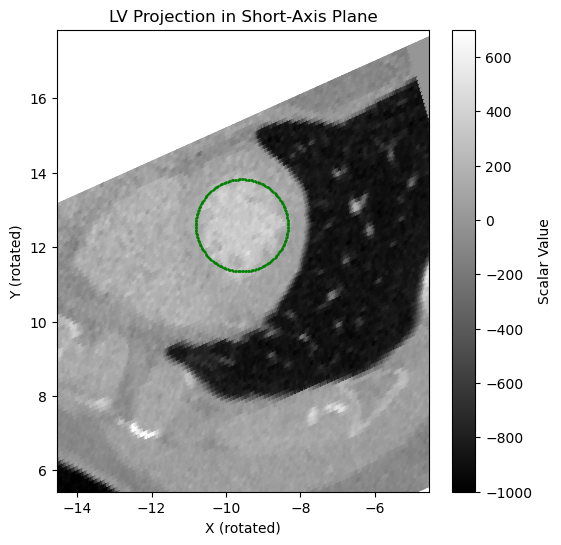

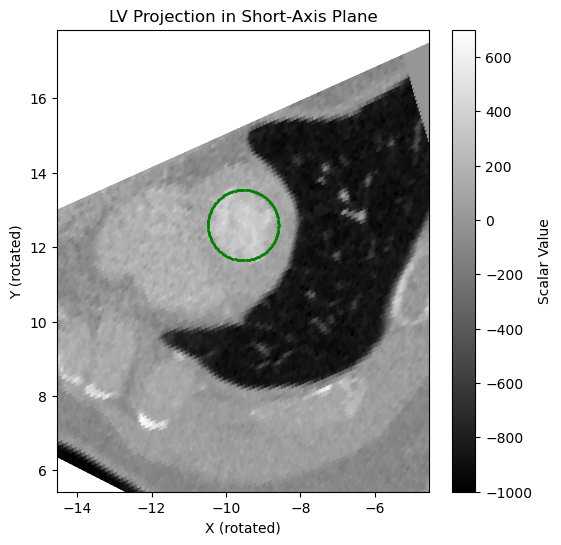

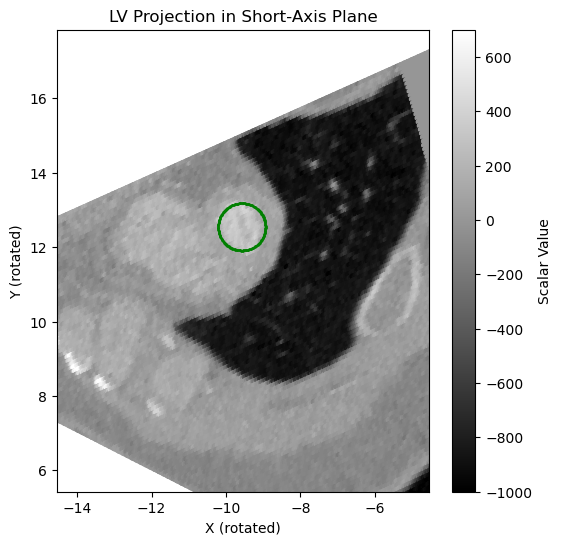

In [20]:
LV_CenterLine = Line(point_1, point_2, N_Slices)
Area = 0
for i in range(3,N_Slices):
    center = LV_CenterLine.GetPoint(i)
    slice_ = SliceWPlane(image, center, CL_direction)
    BloodPool = ThresholdInBetween(slice_, scalar_array_name, 200, 700)
    BloodPool = ExtractSurface(LargestConnectedRegion(BloodPool))

    bp_centroid = GetCentroid(BloodPool)

    center_rotated = rotation.apply(center)
    centroid_rotated = rotation.apply(bp_centroid)


    new_point_x, new_point_y, scalar_value = Rotate(slice_, scalar_array_name)
    new_point_x_bp, new_point_y_bp, scalar_value_bp = Rotate(BloodPool, scalar_array_name)

    coords_2d = np.column_stack((new_point_x_bp, new_point_y_bp))
    hull = ConvexHull(coords_2d)
    hull_area = hull.volume
    Area += hull_area

    radius = np.sqrt(hull_area/np.pi)
    #print(hull_area, radius)

    x_circle = []
    y_circle = []
    for theta in np.arange(0,np.pi*2, np.pi/100):
        x_circle.append(centroid_rotated[0] + radius*np.cos(theta))
        y_circle.append(centroid_rotated[1] + radius*np.sin(theta))

    plt.figure(figsize=(6, 6))
    sc = plt.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10, vmin=-1000, vmax=700)
    plt.scatter(x_circle, y_circle, color='green', s = 0.8)
    plt.colorbar(sc, label='Scalar Value')
    plt.axis('equal')
    plt.xlabel('X (rotated)')
    plt.ylabel('Y (rotated)')
    plt.xlim([center_rotated[0]-5, center_rotated[0]+5])
    plt.ylim([center_rotated[1]-5, center_rotated[1]+5])
    plt.title('LV Projection in Short-Axis Plane')
    plt.show()


In [21]:
Volume = Area*slice_thickness
Volume

111.64666819873034

## Interactive Implementation

 - press a point on the endocardium and return x and y value of that point
 - add a dot at the selected point
 - select several points
 - draw a ray from the centroid to the point on the endocardium or the point on the circle (which has max length)
 - replace the point on the circle with the selected point
 - redraw the new circle with new revised points
 - add a smoothing filter (Fourirer or MAV) and redraw the endocardium
 - calculate the surface area of the blood within endocardium
 - calculate the volume using surface x slice thickness

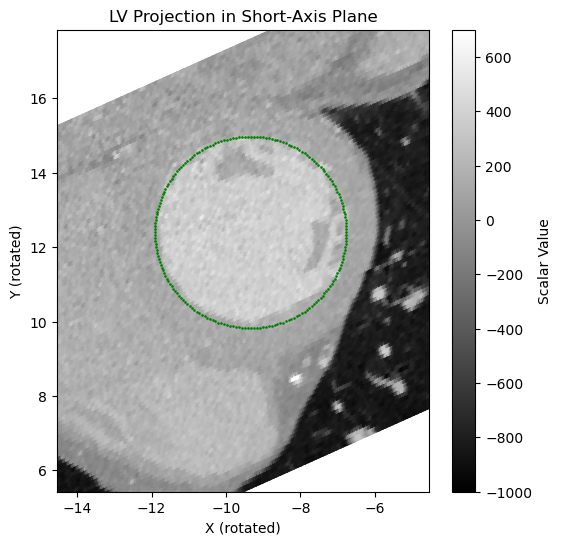

In [27]:
from matplotlib.widgets import Cursor



center = LV_CenterLine.GetPoint(5)
slice_ = SliceWPlane(image, center, CL_direction)
BloodPool = ThresholdInBetween(slice_, scalar_array_name, 200, 700)
BloodPool = ExtractSurface(LargestConnectedRegion(BloodPool))

bp_centroid = GetCentroid(BloodPool)

center_rotated = rotation.apply(center)
centroid_rotated = rotation.apply(bp_centroid)


new_point_x, new_point_y, scalar_value = Rotate(slice_, scalar_array_name)
new_point_x_bp, new_point_y_bp, scalar_value_bp = Rotate(BloodPool, scalar_array_name)

coords_2d = np.column_stack((new_point_x_bp, new_point_y_bp))
hull = ConvexHull(coords_2d)
hull_area = hull.volume
Area += hull_area

radius = np.sqrt(hull_area/np.pi)
#print(hull_area, radius)

x_circle = []
y_circle = []
for theta in np.arange(0,np.pi*2, np.pi/100):
    x_circle.append(centroid_rotated[0] + radius*np.cos(theta))
    y_circle.append(centroid_rotated[1] + radius*np.sin(theta))


fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(new_point_x, new_point_y, c=scalar_value, cmap='gray', s=10, vmin=-1000, vmax=700)
ax.scatter(x_circle, y_circle, color='green', s = 0.8)

cursor = Cursor(ax, horizOn= True, vertOn= True, linewidth = 2.0, color = 'red')
fig.colorbar(sc, label='Scalar Value')
ax.axis('equal')
ax.set_xlabel('X (rotated)')
ax.set_ylabel('Y (rotated)')
ax.set_xlim([center_rotated[0]-5, center_rotated[0]+5])
ax.set_ylim([center_rotated[1]-5, center_rotated[1]+5])
ax.set_title('LV Projection in Short-Axis Plane')
plt.show()

In [29]:

theta = 2 * np.pi * np.linspace(0, 1, 5)
y = np.c_[np.cos(theta), np.sin(theta)]
y

array([[ 1.0000000e+00,  0.0000000e+00],
       [ 6.1232340e-17,  1.0000000e+00],
       [-1.0000000e+00,  1.2246468e-16],
       [-1.8369702e-16, -1.0000000e+00],
       [ 1.0000000e+00, -2.4492936e-16]])